# NLTK y SpaCy

Con este par de librerías, además de resolver tareas relacionadas con el español, nos introducimos al campo del **Procesamiento del Lenguaje **Natural (PLN).

Para entender un poco este campo, deben realizar esta [lectura](https://drive.google.com/file/d/19uxft3JcuQTHkLow02cNc9KL1ULEhUNr/view?usp=sharing).

Recordando el contenido de la última sesión, antes de usar una librería, hay que instalarla. En el caso de SpaCy, pueden copiar este código en el IDLE de Python:

```
# pip install spacy
```

Adicionalmente, podemos dejar que PyCharm haga la instalación por nosotros. Para ello, recuerden que deben insertar el comando **import** y, una vez que aparezca el mensaje de instalación en el editor, dar click para que se instale de forma automática:

```
# import spacy
```

Al igual que NLTK, SpaCy es una librería pensada para resolver diversas tareas relacionadas con el PLN. Una gran ventaja sobre NLTK es que sus algoritmos están adaptados a las características de varias lenguas, no sólo la inglesa.

En este [link](https://spacy-io.translate.goog/usage/linguistic-features?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=sge&_x_tr_hist=true) pueden documentarse del tipo de procesamientos lingüísticos que se pueden realizar con SpaCy. Ahí mismo encontrarán el resto de documentación de la librería.

Lo primero que vamos a realizar es repasar algunos de los procedimientos que vimos anteriormente con NLTK. Para ello, aunque ya está instalada la librería, hay que definir en nuestro código que la vamos a usar mediante el comando **import LIBRARY** o, si sólo usaremos alguno de sus módulos, con el comando **from NLTK import MODULE**.

In [ ]:
## Importar librerías y/o módulos

import nltk
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize
from nltk import pos_tag


Antes de continuar, descarga el [archivo](https://drive.google.com/file/d/1wXlAII2ZDxSL6q1ErBCVnpAgQI7DZomz/view?usp=sharing) que trabajaremos en esta sesión.

Es la versión en TXT de *El amor en los tiempos del cólera* de García Márquez. Usaremos esta obra como corpus dada la cantidad de palabras que tiene, la cual sobrepasa los anteriores corpus que hemos trabajado. Ello permitirá evaluar la importancia de una implementación computacionalmente eficiente.

In [ ]:
## Vamos a probar la anotación POS en español con NLTK para evaluar cómo funciona en esta lengua
## Cargamos el corpus

with open("atc.txt", "r", encoding='utf8') as f:
    corpus = f.read()

In [ ]:
## Posteriormente, tokenizamos con los métodos de NLTK
tokens = word_tokenize(corpus)
tags = pos_tag(tokens)

In [ ]:
## Es probable que les aparezca el error de que no encuentra ciertos módulos, lo solucionamos descargándolos

#nltk.download('punkt_tab')
#nltk.download('punkt')
#nltk.download('averaged_perceptron_tagger_eng')

In [ ]:
## Ya que descagamos los módulos, podemos comentarlos y ejecutar de nuevo la tokenización
tokens = word_tokenize(corpus)
tags = pos_tag(tokens)

In [ ]:
## Vemos las etiquetas
for i in tags:
  print(i)

* ¿Hizo un buen trabajo NLTK con español?
* ¿Qué errores/aciertos tuvo de manera general?
* ¿Cuánto tiempo se tardó en etiquetar?

## Haciendo POS tagging con SpaCy

Usaremos el mismo corpus (y la misma variable en la que lo cargamos) para comparar el resultado con un algoritmo específico para español.

In [ ]:
## Importamos librería

import spacy
import spacy.cli

In [ ]:
## Descargamos el modelo para el español

spacy.cli.download('es_core_news_sm')  #descarga el modelo de entrenamiento para español, varía de idioma a idioma
                                       #Una vez descargado, lo pueden comentar

Noten que el modelo es específico para cada lengua. Si queremos descargar el modelo para otra lengua, debemos cambiar el ID de la lengua por el ID de aquélla que queremos usar, por ejemplo, si queremos trabajar en inglés, la línea quedaría así:

```
spacy.cli.download('en_core_news_sm')  
```

Para sueco:
```
spacy.cli.download('se_core_news_sm')  
```
No olviden consultar la documentación para saber cuál es el nombre del modelo para la [lengua](https://spacy-io.translate.goog/usage/models?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc&_x_tr_hist=true) que les interese.

**Nota**: No es recomendable que cambien el nombre del modelo, pues a pesar de que pueden tener un control claro sobre los nombres de sus variables, es probables que haya dependencias que se referencian con el nombre original y, al no encontrarlo, se generará el error de no encontrar el módulo.




In [ ]:
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger_eng')

In [ ]:
## Tokenizamos de nuevo con NLTK, pero con otra variable para comparar el desempeño y que no se sobreescriban los datos

words = word_tokenize(corpus, 'spanish')
print(tokens)

In [ ]:
## Con este método la tokenización se hace considerando oraciones, a diferencia de la primera que lo hace a nivel palabra
sentences = sent_tokenize(corpus)
print(sentences)
print(len(sentences))

# Este método nos será muy útil cuando trabajemos con oraciones en Pandas

In [ ]:
## En este momento nos interesa trabajar a nivel palabra, por lo tanto, volvemos a la varible words.
## En esta varible los datos están en una LIST, pero SpaCy espera un STR, por lo que tenemos que convertir

words_clean = ' '.join(tokens)

In [ ]:
## Cargamos el modelo para español en una variable

model = spacy.load('es_core_news_sm')


In [ ]:
## Ahora, lo ejecutamos
texto = model(words_clean)

En este proceso es donde notaremos la importancia de una implementación eficiente. Aunque el corpus no es tan grande, comparado con los corpus actuales, el tiempo que se llevó para su anotación es mayor que con el módulo de NLTK. Lo que resta es evaluar qué tan bueno o malo es en relación con su antecesor.

In [ ]:
# Vamos revisar las etiquetas de cada palabra

for i in texto:
    print(i.text, i.pos_)

**Nota**: fíjense que, a diferencia de los métodos que hemos usado en otras ocasiones, con SpaCy se habilitan nuevos y, para imprimir la información que necesitamos, requerimos saber cuál es el método apropiado.

En este caso, usamos la variable **i** más el método **.text** y **.pos_**, ambos sin paréntesis.
Este tipo de particularidades deben aprenderse consultando la documentación.

### **Práctica 1**

Consulta la documentación y utiliza algún otro método para obtener más información del proceso de anotación. Guarda el resultado en un archivo TXT.

### Otras posibilidades

Ejemplo de lo que se puede hacer con Spacy.
Código tomado de la documentación y adaptado al español

In [ ]:


from spacy import displacy
nlp = spacy.load("es_core_news_sm")

text = 'La casa de Juan está por alla' #That house is already sold'
doc = nlp(text) # Process the text to create a Doc object
displacy.serve(doc, style="dep")

A partir de lo anterior, pueden darse cuenta de las posibilidades que estas librerías tienen. Sólo hay que tener en cuenta qué es lo que necesitan de entrada, en el caso del POS tagging con SpaCy, el hecho de que etiqueta los datos en formato STR. Esto puede ser más eficiente, puesto que, recordando lo que vimos al inicio del curso, es muy probable que los textos que carguemos en Python sean en formato STR. Lo mismo sucede con los que guardamos en archivos de salida.

### **Práctica 2**

* Hacer la anotación POS sobre la variable corpus de forma más eficiente, sin convertir los datos a LIST

* Guardar los resultados en **texto_etiquetado.txt**.

* **Bonus**: es seguro que el formato de salida sea poco amigable. Documéntense para tener un archivo de salida como el que aparece en la captura.

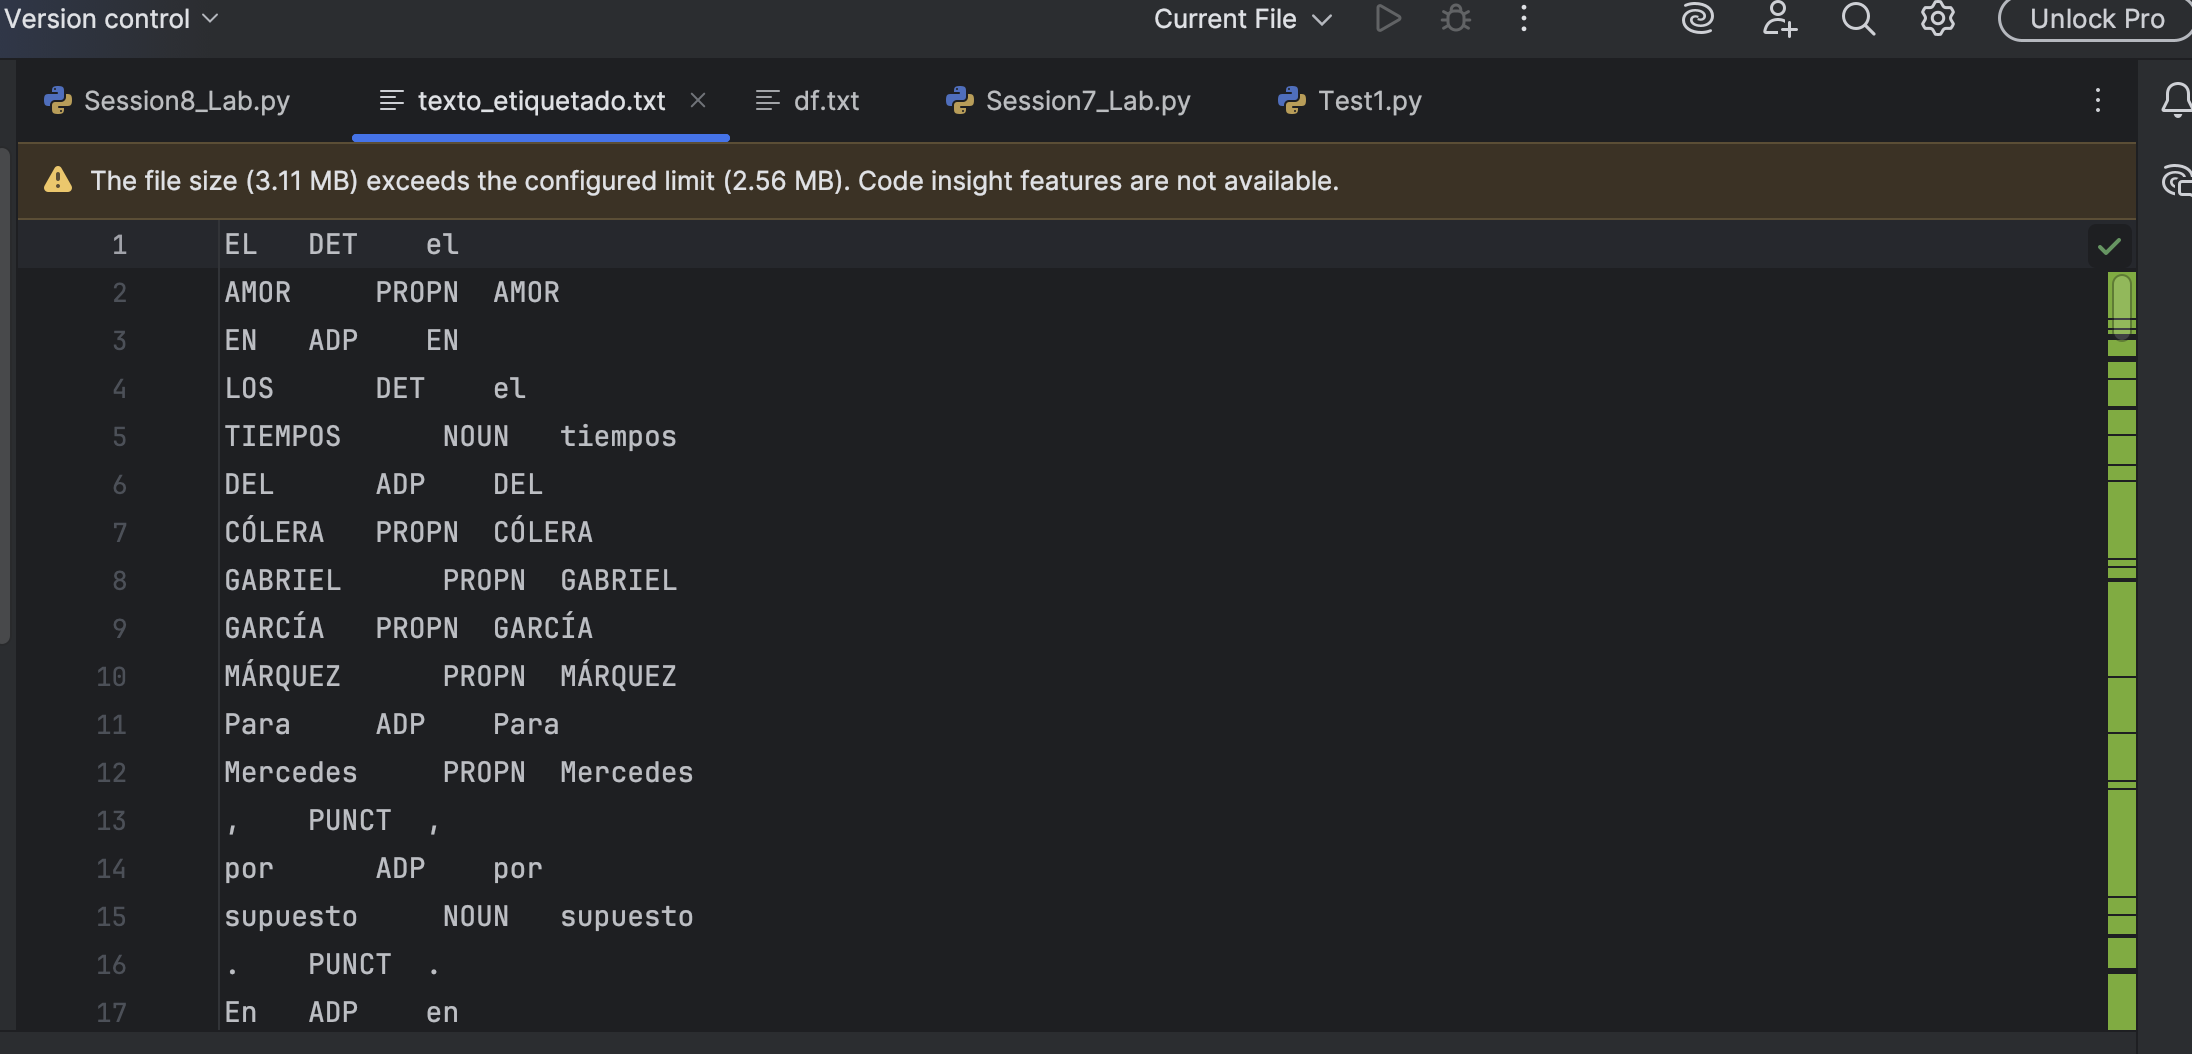

## Combinando librerías

Ya que vimos cómo resolvimos una tarea dependiente de la lengua, podemos tomar decisiones que nos permitan combinar librerías y/o módulos para resolver tareas de forma más eficiente o que tienen mejores resultados si se consideran las particularidades de la lengua, como en este caso.

Lo que haremos ahora, será volver a trabajar con NLTK para sacarle provecho a sus herramientas de similitud.

In [ ]:
# Primero, vamos a ver la lematización para valorar qué tan buena es

from nltk.stem import WordNetLemmatizer
#nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()
corpus_lematizado = [lemmatizer.lemmatize(w) for w in words]

In [ ]:
# Problema: NLTK no lematiza bien en español

print(corpus_lematizado)

In [ ]:
# El resto de procesos funciona bien porque no son dependientes de la lengua

corpus_concordancias = nltk.Text(corpus_lematizado)
corpus_concordancias.concordance('tiempo', 70)



In [ ]:
# Otro ejemplo de que funciona con procesos independientes de la lengua

corpus_concordancias.similar('tiempo')

In [ ]:
corpus_concordancias.concordance_list('tiempo')

In [ ]:
corpus_concordancias.common_contexts(['tiempo', 'hombre'])

In [ ]:
corpus_concordancias.dispersion_plot('tiempo')

In [ ]:
corpus_concordancias.count('tiempo')

In [ ]:
corpus_concordancias.plot(20)

### **Tarea**

* Utiliza la variable corpus del inicio y, con las librerías que consideres más adecuadas, elimina las stopwords y los signos de puntuación. Posteriomente, genera un gráfico con las 50 palabras más frecuentes del corpus.